---
---
---

# Models

---
---
---

<br>

> | **_Language:_** python@3.12.10 |
> | - |

<br>

> | **_Source:_** `notebook/models.ipynb` |
> | - |

<br>

> | **_Configurations:_** `lib/config` |
> | - |

<br>

> | **_Libraries:_** `lib/utils` |
> | - |

<br>

---
---
---

## Dependencies

### Packages

In [1]:
from google.cloud import bigquery
from loguru import logger
from matplotlib import pyplot as plt
from pathlib import Path
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import joblib
import json
import numpy as np
import pandas as pd
import sys
import warnings

ROOT_PATH = Path.cwd().resolve()
if ROOT_PATH.name in ["notebook"]:
    ROOT_PATH = ROOT_PATH.parent
if str(ROOT_PATH) not in sys.path:
    sys.path.insert(0, str(ROOT_PATH))

from config import config as the_config
from utils import etl as the_etl
from utils import pipeline as the_pipeline

from lib import ml_metrics as metrics_lib
from lib.automl import AutoMLClassifier, AutoMLRegressor

# -------------------------

# Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.float_format", "{:.3f}".format)
warnings.filterwarnings("ignore")

### Constants

In [2]:
# Figures
FIGURES = []

# GCP
BQ_CLIENT = bigquery.Client(project=the_config.GCP_PROJECT)

### Paths

In [3]:
# Paths
for path in the_config.PATHS:
    the_config.ensure_path(path)

## DataFrame

In [4]:
query = f"""
	SELECT * FROM `{the_config.BQ_TABLE}`
	ORDER BY TIMESTAMP(
		DATETIME(year, month, day, hour, minute, 0)
	)
"""
train_df = BQ_CLIENT.query(query).to_dataframe()
display(train_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 178919 entries, 0 to 178918
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   date                 178919 non-null  dbdate 
 1   year                 178919 non-null  Int64  
 2   month                178919 non-null  Int64  
 3   day                  178919 non-null  Int64  
 4   hour                 178919 non-null  Int64  
 5   minute               178919 non-null  Int64  
 6   quarter              178919 non-null  Int64  
 7   week_of_year         178919 non-null  Int64  
 8   day_of_year          178919 non-null  Int64  
 9   day_of_week          178919 non-null  Int64  
 10  station              178919 non-null  str    
 11  city                 178919 non-null  str    
 12  province             178919 non-null  str    
 13  latitude             178919 non-null  float64
 14  longitude            178919 non-null  float64
 15  temperature_c        178919 

None

## Training

### Feature Engineering

In [5]:
clf_df = train_df.iloc[-the_config.ML_HYPER_SPACE["sampling"]:].copy()
clf_df, targets_clf = the_pipeline.feature_engineering_clf(
	clf_df, inference=False
)
clf_df = clf_df.assign(
	timestamp=lambda x: pd.to_datetime(
		x[["year", "month", "day", "hour", "minute"]]
	)
)
logger.debug(f"[LIST] Targets ({len(targets_clf)}): {targets_clf}")

# Feature Selection -- Classification
to_drop = [
	*the_config.CLASSIFICATION["to_drop"],
	the_config.CLASSIFICATION["targets"][0],
    "timestamp"
]
to_drop += [c for c in clf_df.columns if c.lower().startswith("conf_")]
X_clf = clf_df.drop(columns=to_drop)
y_clf = clf_df[the_config.CLASSIFICATION["targets"][0]]

2026-08-30 16:26:25.035 | DEBUG    | __main__:<module>:10 - [LIST] Targets (1): ['rain_flag']


In [6]:
reg_df = train_df.iloc[-the_config.ML_HYPER_SPACE["sampling"]:].copy()
reg_df, targets_reg = the_pipeline.feature_engineering_reg(
	reg_df, inference=False
)
reg_df = reg_df.assign(
	timestamp=lambda x: pd.to_datetime(
		x[["year", "month", "day", "hour", "minute"]]
	)
)
logger.debug(f"[LIST] Targets ({len(targets_reg)}): {targets_reg}")

# Feature Selection -- Regression
to_drop = [
	*the_config.REGRESSION["to_drop"],
    *targets_reg,
	"timestamp"
]
to_drop += [c for c in reg_df.columns if c.lower().startswith("conf_")]
X_reg = reg_df.drop(columns=to_drop)
y_reg = reg_df[targets_reg]

2026-08-30 16:26:25.416 | DEBUG    | __main__:<module>:10 - [LIST] Targets (28): ['temperature_c_lead_30', 'humidity_pct_lead_30', 'dew_point_c_lead_30', 'pressure_hpa_lead_30', 'wind_speed_kmh_lead_30', 'wind_x_lead_30', 'wind_y_lead_30', 'temperature_c_lead_60', 'humidity_pct_lead_60', 'dew_point_c_lead_60', 'pressure_hpa_lead_60', 'wind_speed_kmh_lead_60', 'wind_x_lead_60', 'wind_y_lead_60', 'temperature_c_lead_90', 'humidity_pct_lead_90', 'dew_point_c_lead_90', 'pressure_hpa_lead_90', 'wind_speed_kmh_lead_90', 'wind_x_lead_90', 'wind_y_lead_90', 'temperature_c_lead_120', 'humidity_pct_lead_120', 'dew_point_c_lead_120', 'pressure_hpa_lead_120', 'wind_speed_kmh_lead_120', 'wind_x_lead_120', 'wind_y_lead_120']


### Train-Test Split

In [7]:
# Train-Test Split -- Classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
	X_clf, y_clf,
    test_size=the_config.CLASSIFICATION["test_size"],
    shuffle=the_config.CLASSIFICATION["shuffle"],
    random_state=the_config.CLASSIFICATION["seed"]
)

logger.debug(f"{'[LIST]':<8}{'[CLF]':<6}{'Features:':<10}{X_train_clf.columns.tolist()}")
logger.debug(f"{'[LIST]':<8}{'[CLF]':<6}{'Labels:':<10}{y_train_clf.name}")
logger.debug(f"{'[TRAIN]':<8}{'[CLF]':<6}{'Shape:':<10}{y_train_clf.shape}")
logger.debug(f"{'[TEST]':<8}{'[CLF]':<6}{'Shape:':<10}{y_test_clf.shape}")

2026-08-30 16:26:25.426 | DEBUG    | __main__:<module>:9 - [LIST]  [CLF] Features: ['latitude', 'longitude', 'temperature_c', 'humidity_pct', 'dew_point_c', 'wind_speed_kmh', 'pressure_hpa']
2026-08-30 16:26:25.427 | DEBUG    | __main__:<module>:10 - [LIST]  [CLF] Labels:   rain_flag
2026-08-30 16:26:25.427 | DEBUG    | __main__:<module>:11 - [TRAIN] [CLF] Shape:    (30643,)
2026-08-30 16:26:25.427 | DEBUG    | __main__:<module>:12 - [TEST]  [CLF] Shape:    (7661,)


In [8]:
# Train-Test Split -- Regression
X_train_reg = X_reg.iloc[:-the_config.INF_ROWS]
y_train_reg = y_reg.iloc[:-the_config.INF_ROWS]
X_test_reg = X_reg.iloc[-the_config.INF_ROWS:]
y_test_reg = y_reg.iloc[-the_config.INF_ROWS:]

logger.debug(f"{'[LIST]':<8}{'[REG]':<6}{'Features:':<10}{X_train_reg.columns.tolist()}")
logger.debug(f"{'[LIST]':<8}{'[REG]':<6}{'Labels:':<10}{y_train_reg.columns.tolist()}")
logger.debug(f"{'[TRAIN]':<8}{'[REG]':<6}{'Shape:':<10}{y_train_reg.shape}")
logger.debug(f"{'[TEST]':<8}{'[REG]':<6}{'Shape:':<10}{y_test_reg.shape}")

2026-08-30 16:26:25.431 | DEBUG    | __main__:<module>:7 - [LIST]  [REG] Features: ['year', 'month', 'day', 'hour', 'minute', 'quarter', 'week_of_year', 'day_of_year', 'day_of_week', 'latitude', 'longitude', 'temperature_c', 'humidity_pct', 'dew_point_c', 'wind_speed_kmh', 'pressure_hpa', 'wind_x', 'wind_y', 'temperature_c_lag_1', 'temperature_c_lag_2', 'temperature_c_lag_3', 'temperature_c_lag_6', 'temperature_c_lag_12', 'temperature_c_lag_18', 'temperature_c_lag_24', 'humidity_pct_lag_1', 'humidity_pct_lag_2', 'humidity_pct_lag_3', 'humidity_pct_lag_6', 'humidity_pct_lag_12', 'humidity_pct_lag_18', 'humidity_pct_lag_24', 'dew_point_c_lag_1', 'dew_point_c_lag_2', 'dew_point_c_lag_3', 'dew_point_c_lag_6', 'dew_point_c_lag_12', 'dew_point_c_lag_18', 'dew_point_c_lag_24', 'pressure_hpa_lag_1', 'pressure_hpa_lag_2', 'pressure_hpa_lag_3', 'pressure_hpa_lag_6', 'pressure_hpa_lag_12', 'pressure_hpa_lag_18', 'pressure_hpa_lag_24', 'wind_speed_kmh_lag_1', 'wind_speed_kmh_lag_2', 'wind_speed_km

### Models

In [9]:
# Dummy Classifier
dummy_clf = DummyClassifier(strategy="prior")
dummy_clf.fit(X_train_clf, y_train_clf)
display(dummy_clf)

# Dummy Regressor
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_train_reg, y_train_reg)
display(dummy_reg)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.69,0.31]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](7,)","['latitude','longitude','temperature_c',...,'dew_point_c','wind_speed_kmh', 'pressure_hpa']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,7
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None
Name,Type,Value
"constant_ constant_: ndarray of shape (1, n_outputs)Mean or median or quantile of the training targets or constant valuegiven by the user.","ndarray[float64](1, 28)","[[23.21,75.72,18.5 ,..., 3.84, 0.03, 0.17]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](151,)","['year','month','day',...,'wind_y_std_24','wind_y_min_24','wind_y_max_24']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,151
n_outputs_ n_outputs_: intNumber of outputs.,int,28


In [10]:
# AutoML Classifier -- Random Forest
model_path = the_config.MODELS_PATH / "random_forest_classifier.joblib"
if model_path.exists():
    rf_clf = joblib.load(model_path)

else:
	rf_clf = AutoMLClassifier(
		**the_config.ML_HYPER_SPACE["automl_clf"],
		estimator_list=["rf"],
		seed=the_config.CLASSIFICATION["seed"]
	)
	rf_clf.fit(X_train_clf, y_train_clf)
display(rf_clf)

# AutoML Regressor -- Random Forest
model_path = the_config.MODELS_PATH / "random_forest_regressor.joblib"
if model_path.exists():
    rf_reg = joblib.load(model_path)

else:
	rf_reg = AutoMLRegressor(
		**the_config.ML_HYPER_SPACE["automl_reg"],
		estimator_list=["rf"],
		seed=the_config.REGRESSION["seed"]
	)
	rf_reg.fit(X_train_reg, y_train_reg)
display(rf_reg)

[flaml.automl.logger: 08-30 16:26:25] {2375} INFO - task = classification
[flaml.automl.logger: 08-30 16:26:25] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 08-30 16:26:25] {2489} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 08-30 16:26:25] {2606} INFO - List of ML learners in AutoML Run: ['rf']
[flaml.automl.logger: 08-30 16:26:25] {2911} INFO - iteration 0, current learner rf
[flaml.automl.logger: 08-30 16:26:25] {3046} INFO - Estimated sufficient time budget=642s. Estimated necessary time budget=1s.
[flaml.automl.logger: 08-30 16:26:25] {3097} INFO -  at 0.1s,	estimator rf's best error=1.7158e-01,	best estimator rf's best error=1.7158e-01
[flaml.automl.logger: 08-30 16:26:25] {2911} INFO - iteration 1, current learner rf
[flaml.automl.logger: 08-30 16:26:25] {3097} INFO -  at 0.3s,	estimator rf's best error=1.7158e-01,	best estimator rf's best error=1.7158e-01
[flaml.automl.logger: 08-30 16:26:25] {2911} INFO - iteration 2, current learner rf
[fl

[flaml.automl.logger: 08-30 16:27:25] {2375} INFO - task = regression
[flaml.automl.logger: 08-30 16:27:25] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 08-30 16:27:25] {2489} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 08-30 16:27:25] {2606} INFO - List of ML learners in AutoML Run: ['rf']
[flaml.automl.logger: 08-30 16:27:25] {2911} INFO - iteration 0, current learner rf
[flaml.automl.logger: 08-30 16:27:26] {3046} INFO - Estimated sufficient time budget=5817s. Estimated necessary time budget=6s.
[flaml.automl.logger: 08-30 16:27:26] {3097} INFO -  at 1.3s,	estimator rf's best error=1.1743e+00,	best estimator rf's best error=1.1743e+00
[flaml.automl.logger: 08-30 16:27:26] {2911} INFO - iteration 1, current learner rf
[flaml.automl.logger: 08-30 16:27:27] {3097} INFO -  at 2.0s,	estimator rf's best error=1.1649e+00,	best estimator rf's best error=1.1649e+00
[flaml.automl.logger: 08-30 16:27:27] {2911} INFO - iteration 2, current learner rf
[flaml.auto

In [11]:
# AutoML Classifier -- LGBM
model_path = the_config.MODELS_PATH / "lgbm_classifier.joblib"
if model_path.exists():
    lgbm_clf = joblib.load(model_path)

else:
	lgbm_clf = AutoMLClassifier(
		**the_config.ML_HYPER_SPACE["automl_clf"],
		estimator_list=["lgbm"],
		seed=the_config.CLASSIFICATION["seed"]
	)
	lgbm_clf.fit(X_train_clf, y_train_clf)
display(lgbm_clf)

# AutoML Regressor -- LGBM
model_path = the_config.MODELS_PATH / "lgbm_regressor.joblib"
if model_path.exists():
    lgbm_reg = joblib.load(model_path)

else:
	lgbm_reg = AutoMLRegressor(
		**the_config.ML_HYPER_SPACE["automl_reg"],
		estimator_list=["lgbm"],
		seed=the_config.REGRESSION["seed"]
	)
	lgbm_reg.fit(X_train_reg, y_train_reg)
display(lgbm_reg)

[flaml.automl.logger: 08-30 16:32:04] {2375} INFO - task = classification
[flaml.automl.logger: 08-30 16:32:04] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 08-30 16:32:04] {2489} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 08-30 16:32:04] {2606} INFO - List of ML learners in AutoML Run: ['lgbm']
[flaml.automl.logger: 08-30 16:32:04] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 08-30 16:32:05] {3046} INFO - Estimated sufficient time budget=3141s. Estimated necessary time budget=3s.
[flaml.automl.logger: 08-30 16:32:05] {3097} INFO -  at 0.4s,	estimator lgbm's best error=1.3706e-01,	best estimator lgbm's best error=1.3706e-01
[flaml.automl.logger: 08-30 16:32:05] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 08-30 16:32:05] {3097} INFO -  at 0.4s,	estimator lgbm's best error=1.3706e-01,	best estimator lgbm's best error=1.3706e-01
[flaml.automl.logger: 08-30 16:32:05] {2911} INFO - iteration 2, current

[flaml.automl.logger: 08-30 16:33:09] {2375} INFO - task = regression
[flaml.automl.logger: 08-30 16:33:09] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 08-30 16:33:09] {2489} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 08-30 16:33:09] {2606} INFO - List of ML learners in AutoML Run: ['lgbm']
[flaml.automl.logger: 08-30 16:33:09] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 08-30 16:33:09] {3046} INFO - Estimated sufficient time budget=2056s. Estimated necessary time budget=2s.
[flaml.automl.logger: 08-30 16:33:09] {3097} INFO -  at 0.7s,	estimator lgbm's best error=2.2826e+00,	best estimator lgbm's best error=2.2826e+00
[flaml.automl.logger: 08-30 16:33:09] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 08-30 16:33:09] {3097} INFO -  at 0.9s,	estimator lgbm's best error=2.2826e+00,	best estimator lgbm's best error=2.2826e+00
[flaml.automl.logger: 08-30 16:33:09] {2911} INFO - iteration 2, current learner 

In [12]:
# AutoML Classifier -- XGBoost
model_path = the_config.MODELS_PATH / "xgboost_classifier.joblib"
if model_path.exists():
    xgb_clf = joblib.load(model_path)

else:
	xgb_clf = AutoMLClassifier(
		**the_config.ML_HYPER_SPACE["automl_clf"],
		estimator_list=["xgboost"],
		seed=the_config.CLASSIFICATION["seed"]
	)
	xgb_clf.fit(X_train_clf, y_train_clf)
display(xgb_clf)

# AutoML Regressor -- XGBoost
model_path = the_config.MODELS_PATH / "xgboost_regressor.joblib"
if model_path.exists():
    xgb_reg = joblib.load(model_path)

else:
	xgb_reg = AutoMLRegressor(
		**the_config.ML_HYPER_SPACE["automl_reg"],
		estimator_list=["xgboost"],
		seed=the_config.REGRESSION["seed"]
	)
	xgb_reg.fit(X_train_reg, y_train_reg)
display(xgb_reg)

[flaml.automl.logger: 08-30 16:39:11] {2375} INFO - task = classification
[flaml.automl.logger: 08-30 16:39:11] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 08-30 16:39:11] {2489} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 08-30 16:39:11] {2606} INFO - List of ML learners in AutoML Run: ['xgboost']
[flaml.automl.logger: 08-30 16:39:11] {2911} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 08-30 16:39:11] {3046} INFO - Estimated sufficient time budget=537s. Estimated necessary time budget=1s.
[flaml.automl.logger: 08-30 16:39:11] {3097} INFO -  at 0.1s,	estimator xgboost's best error=1.5008e-01,	best estimator xgboost's best error=1.5008e-01
[flaml.automl.logger: 08-30 16:39:11] {2911} INFO - iteration 1, current learner xgboost
[flaml.automl.logger: 08-30 16:39:11] {3097} INFO -  at 0.2s,	estimator xgboost's best error=1.4787e-01,	best estimator xgboost's best error=1.4787e-01
[flaml.automl.logger: 08-30 16:39:11] {2911} INFO - 

[flaml.automl.logger: 08-30 16:40:15] {2375} INFO - task = regression
[flaml.automl.logger: 08-30 16:40:15] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 08-30 16:40:15] {2489} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 08-30 16:40:15] {2606} INFO - List of ML learners in AutoML Run: ['xgboost']
[flaml.automl.logger: 08-30 16:40:15] {2911} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 08-30 16:40:15] {3046} INFO - Estimated sufficient time budget=1554s. Estimated necessary time budget=2s.
[flaml.automl.logger: 08-30 16:40:15] {3097} INFO -  at 0.7s,	estimator xgboost's best error=2.2826e+00,	best estimator xgboost's best error=2.2826e+00
[flaml.automl.logger: 08-30 16:40:15] {2911} INFO - iteration 1, current learner xgboost
[flaml.automl.logger: 08-30 16:40:15] {3097} INFO -  at 0.8s,	estimator xgboost's best error=2.2826e+00,	best estimator xgboost's best error=2.2826e+00
[flaml.automl.logger: 08-30 16:40:15] {2911} INFO - iteratio

In [13]:
# AutoML Classifier
model_path = the_config.MODELS_PATH / "automl_classifier.joblib"
if model_path.exists():
    automl_clf = joblib.load(model_path)

else:
	automl_clf = AutoMLClassifier(
		**the_config.ML_HYPER_SPACE["automl_clf"],
		estimator_list=[
            "rf",
            "lgbm",
            "xgboost"
        ],
		seed=the_config.CLASSIFICATION["seed"]
	)
	automl_clf.fit(X_train_clf, y_train_clf)
display(automl_clf)

# AutoML Regressor
model_path = the_config.MODELS_PATH / "automl_regressor.joblib"
if model_path.exists():
    automl_reg = joblib.load(model_path)

else:
	automl_reg = AutoMLRegressor(
		**the_config.ML_HYPER_SPACE["automl_reg"],
		estimator_list=[
			"rf",
			"lgbm",
			"xgboost"
		],
		seed=the_config.REGRESSION["seed"]
	)
	automl_reg.fit(X_train_reg, y_train_reg)
display(automl_reg)

[flaml.automl.logger: 08-30 16:46:03] {2375} INFO - task = classification
[flaml.automl.logger: 08-30 16:46:03] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 08-30 16:46:03] {2489} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 08-30 16:46:03] {2606} INFO - List of ML learners in AutoML Run: ['rf', 'lgbm', 'xgboost']
[flaml.automl.logger: 08-30 16:46:03] {2911} INFO - iteration 0, current learner rf
[flaml.automl.logger: 08-30 16:46:03] {3046} INFO - Estimated sufficient time budget=761s. Estimated necessary time budget=1s.
[flaml.automl.logger: 08-30 16:46:03] {3097} INFO -  at 0.3s,	estimator rf's best error=1.7158e-01,	best estimator rf's best error=1.7158e-01
[flaml.automl.logger: 08-30 16:46:03] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 08-30 16:46:03] {3097} INFO -  at 0.4s,	estimator lgbm's best error=1.3706e-01,	best estimator lgbm's best error=1.3706e-01
[flaml.automl.logger: 08-30 16:46:03] {2911} INFO - iteration 

[flaml.automl.logger: 08-30 16:47:03] {2375} INFO - task = regression
[flaml.automl.logger: 08-30 16:47:03] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 08-30 16:47:04] {2489} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 08-30 16:47:04] {2606} INFO - List of ML learners in AutoML Run: ['rf', 'lgbm', 'xgboost']
[flaml.automl.logger: 08-30 16:47:04] {2911} INFO - iteration 0, current learner rf
[flaml.automl.logger: 08-30 16:47:04] {3046} INFO - Estimated sufficient time budget=6242s. Estimated necessary time budget=6s.
[flaml.automl.logger: 08-30 16:47:04] {3097} INFO -  at 1.6s,	estimator rf's best error=1.1743e+00,	best estimator rf's best error=1.1743e+00
[flaml.automl.logger: 08-30 16:47:04] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 08-30 16:47:04] {3097} INFO -  at 1.9s,	estimator lgbm's best error=2.2826e+00,	best estimator rf's best error=1.1743e+00
[flaml.automl.logger: 08-30 16:47:04] {2911} INFO - iteration 2, current

## Evaluation

In [14]:
models_clf = {
    "Dummy Classifier": { "model": dummy_clf, "metrics": {} },
    "Random Forest Classifier": { "model": rf_clf, "metrics": {} },
    "LGBM Classifier": { "model": lgbm_clf, "metrics": {} },
    "XGBoost Classifier": { "model": xgb_clf, "metrics": {} },
	"AutoML Classifier": { "model": automl_clf, "metrics": {} }
}
for model_name, model_info in models_clf.items():

	logger.debug(f"Model: {model_name}")
	model = model_info["model"]
	model_metrics = model_info["metrics"]

	y_true_train_clf = y_train_clf
	y_true_test_clf = y_test_clf
	y_pred_train_clf = model.predict(X_train_clf)
	y_pred_test_clf = model.predict(X_test_clf)

	model_metrics[the_config.CLASSIFICATION["targets"][0]] = {}
	metrics_lib.compute_metrics_clf(
		model_metrics[the_config.CLASSIFICATION["targets"][0]],
		y_true_train_clf,
		y_pred_train_clf,
		model_classes=[0, 1],
		set="TRAIN"
	)
	metrics_lib.compute_metrics_clf(
		model_metrics[the_config.CLASSIFICATION["targets"][0]],
		y_true_test_clf,
		y_pred_test_clf,
		model_classes=[0, 1],
		set="TEST"
	)

2026-08-30 16:52:08.350 | DEBUG    | __main__:<module>:10 - Model: Dummy Classifier
2026-08-30 16:52:08.392 | DEBUG    | __main__:<module>:10 - Model: Random Forest Classifier
2026-08-30 16:52:08.540 | DEBUG    | __main__:<module>:10 - Model: LGBM Classifier
2026-08-30 16:52:09.038 | DEBUG    | __main__:<module>:10 - Model: XGBoost Classifier
2026-08-30 16:52:09.107 | DEBUG    | __main__:<module>:10 - Model: AutoML Classifier


In [15]:
models_reg = {
	"Dummy Regressor": { "model": dummy_reg, "metrics": {} },
    "Random Forest Regressor": { "model": rf_reg, "metrics": {} },
    "LGBM Regressor": { "model": lgbm_reg, "metrics": {} },
    "XGBoost Regressor": { "model": xgb_reg, "metrics": {} },
	"AutoML Regressor": { "model": automl_reg, "metrics": {} }
}
for model_name, model_info in models_reg.items():

	logger.debug(f"Model: {model_name}")
	model = model_info["model"]
	model_metrics = model_info["metrics"]

	y_true_train_reg = y_train_reg
	y_true_test_reg = y_test_reg
	y_pred_train_reg = pd.DataFrame(
		model.predict(X_train_reg),
		columns=y_train_reg.columns,
		index=y_train_reg.index
	)
	y_pred_test_reg = pd.DataFrame(
		model.predict(X_test_reg),
		columns=y_test_reg.columns,
		index=y_test_reg.index
	)

	for forecast in the_config.FENG_FORECASTS:

		model_metrics[forecast] = {}
		for feature in the_config.REGRESSION["targets"]:

			col = f"{feature}_lead_{forecast}"
			model_metrics[forecast][feature] = {}
			metrics_lib.compute_metrics_reg(
				model_metrics[forecast][feature],
				y_true_train_reg[[col]],
				y_pred_train_reg[[col]],
				set="TRAIN"
			)
			metrics_lib.compute_metrics_reg(
				model_metrics[forecast][feature],
				y_true_test_reg[[col]],
				y_pred_test_reg[[col]],
				set="TEST"
			)

2026-08-30 16:52:09.261 | DEBUG    | __main__:<module>:10 - Model: Dummy Regressor
2026-08-30 16:52:09.384 | DEBUG    | __main__:<module>:10 - Model: Random Forest Regressor
2026-08-30 16:52:11.413 | DEBUG    | __main__:<module>:10 - Model: LGBM Regressor
2026-08-30 16:52:14.416 | DEBUG    | __main__:<module>:10 - Model: XGBoost Regressor
2026-08-30 16:52:16.744 | DEBUG    | __main__:<module>:10 - Model: AutoML Regressor


## Results

count   30643.000
mean        0.315
std         0.464
min         0.000
25%         0.000
50%         0.000
75%         1.000
max         1.000
Name: rain_flag, dtype: float64

,Model,Target,Set,Size,Accuracy,Precision,Recall,F1 Score,Confusion Matrix
0,Dummy Classifier,rain_flag,TRAIN,30643,0.685,0.000,0.000,0.000,"[[20993, 0], [9650, 0]]"
1,Dummy Classifier,rain_flag,TEST,7661,0.695,0.000,0.000,0.000,"[[5327, 0], [2334, 0]]"
2,Random Forest Classifier,rain_flag,TRAIN,30643,1.000,1.000,0.999,1.000,"[[20992, 1], [7, 9643]]"
3,Random Forest Classifier,rain_flag,TEST,7661,0.992,0.988,0.985,0.986,"[[5298, 29], [34, 2300]]"
4,LGBM Classifier,rain_flag,TRAIN,30643,1.000,0.999,0.999,0.999,"[[20988, 5], [7, 9643]]"
5,LGBM Classifier,rain_flag,TEST,7661,0.992,0.989,0.985,0.987,"[[5302, 25], [34, 2300]]"
6,XGBoost Classifier,rain_flag,TRAIN,30643,1.000,1.000,0.999,1.000,"[[20990, 3], [5, 9645]]"
7,XGBoost Classifier,rain_flag,TEST,7661,0.992,0.988,0.986,0.987,"[[5298, 29], [33, 2301]]"
8,AutoML Classifier,rain_flag,TRAIN,30643,1.000,1.000,0.999,1.000,"[[20992, 1], [7, 9643]]"
9,AutoML Classifier,rain_flag,TEST,7661,0.992,0.989,0.985,0.987,"[[5301, 26], [34, 2300]]"


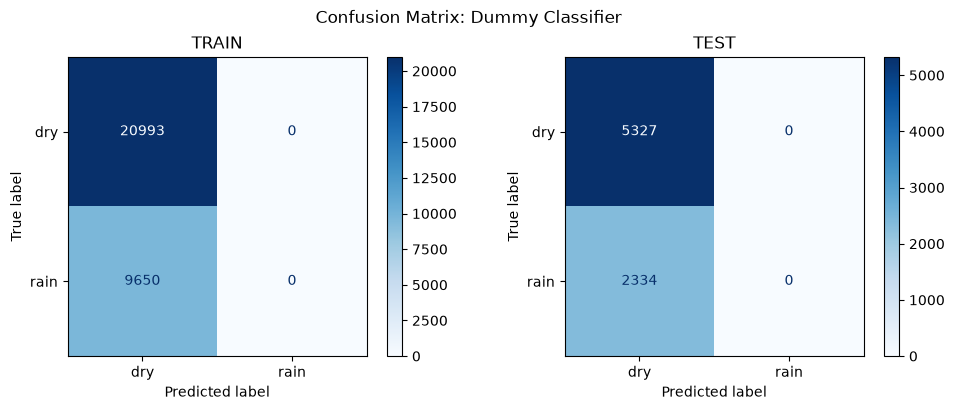

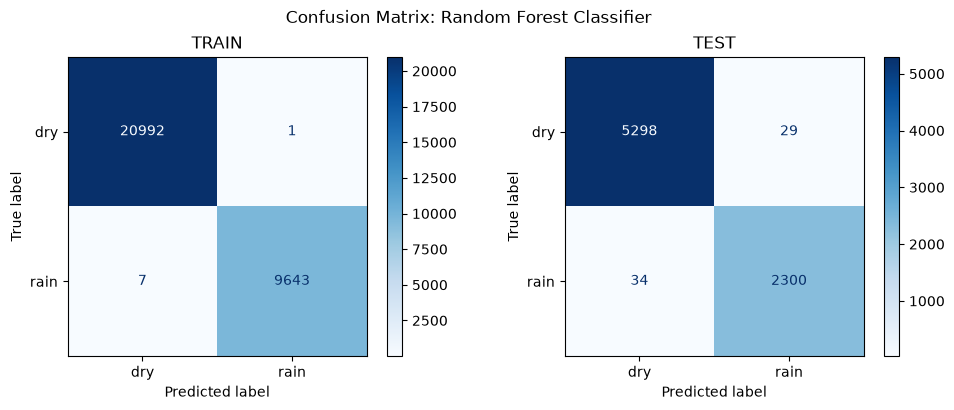

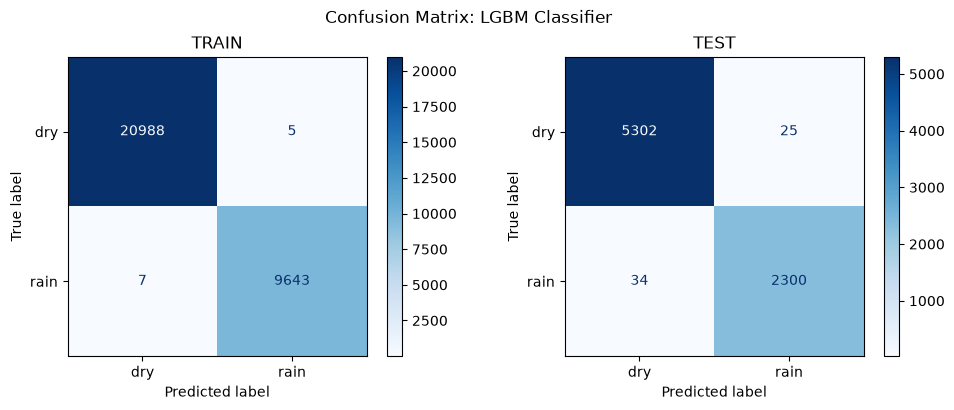

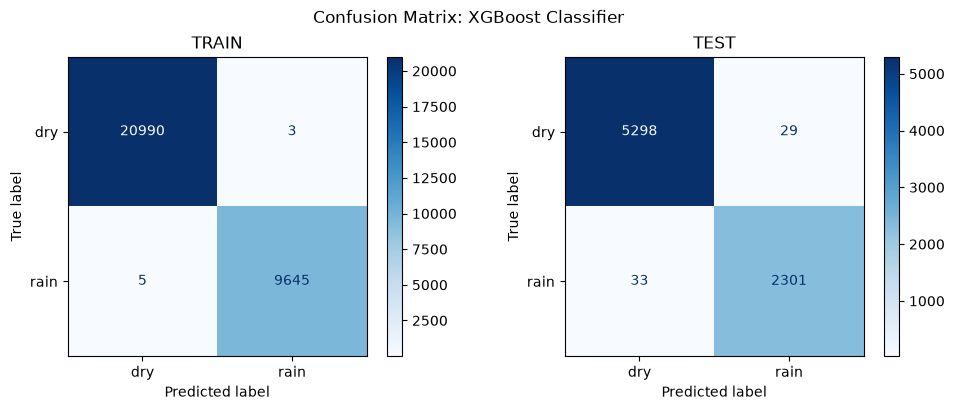

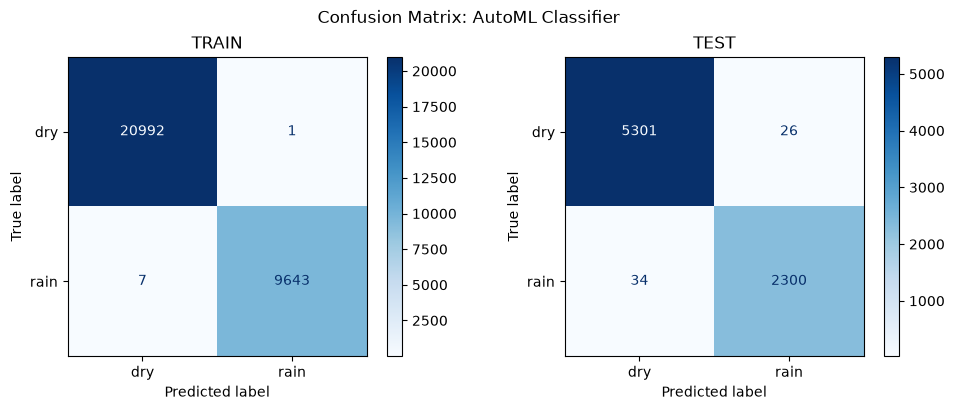

In [16]:
# Metrics -- Classification
rows_clf = []
for model_name, model_info in models_clf.items():

	for target, sets in model_info["metrics"].items():
		for split in ["TRAIN", "TEST"]:

			size, accuracy, precision, recall, f1_score, cm = sets[split]
			rows_clf.append({
				"Model": model_name,
				"Target": target,
				"Set": split,
				"Size": size,
				"Accuracy": accuracy,
				"Precision": precision,
				"Recall": recall,
				"F1 Score": f1_score,
				"Confusion Matrix": cm
			})
metrics_clf_df = (
    pd.DataFrame(rows_clf)
    .reset_index(drop=True)
)

display(y_train_clf.describe())
display(metrics_clf_df)

# Confusion Matrix -- Classification
for model_name in metrics_clf_df["Model"].unique():

    model_results = metrics_clf_df[
        metrics_clf_df["Model"] == model_name
    ]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ax, (_, row) in zip(
        axes,
        (
			model_results
			.set_index("Set")
			.loc[["TRAIN", "TEST"]]
			.reset_index()
			.iterrows()
		)
    ):

        cm = np.array(row["Confusion Matrix"])
        cm = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["dry", "rain"]
        )
        cm.plot(
            ax=ax,
            cmap="Blues",
            values_format="d"
        )
        ax.set_title(row["Set"])

    fig.suptitle(f"Confusion Matrix: {model_name}")
    fig.tight_layout()
    fig.savefig(
        the_config.MODELS_PATH /
        f"{model_name.lower().replace(' ', '_')}_cm.png",
        bbox_inches="tight",
        dpi=300
    )
    FIGURES.append(fig)
    plt.show()
    plt.close(fig)

In [17]:
# Metrics -- Regression
rows_reg = []
for model_name, model_info in models_reg.items():
    for lead, targets in model_info["metrics"].items():
        for target, sets in targets.items():
            for split in ["TRAIN", "TEST"]:

                size, mae, rmse, r2 = sets[split]
                rows_reg.append({
                    "Model": model_name,
                    "Target": target,
                    "Lead": lead,
                    "Set": split,
                    "Size": size,
                    "MAE": mae,
                    "RMSE": rmse,
                    "R2": r2,
                })                
metrics_reg_df = (
    pd.DataFrame(rows_reg)
    .sort_values(["Target", "Lead"])
    .reset_index(drop=True)
)

display(y_train_reg.describe())
display(metrics_reg_df)

,temperature_c_lead_30,humidity_pct_lead_30,dew_point_c_lead_30,pressure_hpa_lead_30,wind_speed_kmh_lead_30,wind_x_lead_30,wind_y_lead_30,temperature_c_lead_60,humidity_pct_lead_60,dew_point_c_lead_60,pressure_hpa_lead_60,wind_speed_kmh_lead_60,wind_x_lead_60,wind_y_lead_60,temperature_c_lead_90,humidity_pct_lead_90,dew_point_c_lead_90,pressure_hpa_lead_90,wind_speed_kmh_lead_90,wind_x_lead_90,wind_y_lead_90,temperature_c_lead_120,humidity_pct_lead_120,dew_point_c_lead_120,pressure_hpa_lead_120,wind_speed_kmh_lead_120,wind_x_lead_120,wind_y_lead_120
count,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000,35185.000
mean,23.211,75.716,18.496,1014.270,3.820,0.065,0.168,23.217,75.713,18.501,1014.262,3.827,0.055,0.171,23.227,75.699,18.506,1014.254,3.837,0.043,0.172,23.238,75.679,18.512,1014.244,3.844,0.033,0.173
std,3.170,10.492,1.773,12.032,5.318,5.181,4.001,3.178,10.500,1.773,12.031,5.321,5.188,4.003,3.187,10.525,1.772,12.031,5.327,5.198,4.007,3.198,10.558,1.771,12.030,5.332,5.205,4.009
min,14.100,38.000,12.400,0.000,0.000,-49.058,-40.200,14.100,38.000,12.400,0.000,0.000,-49.058,-40.200,14.100,38.000,12.400,0.000,0.000,-49.058,-40.200,14.100,38.000,12.400,0.000,0.000,-49.058,-40.200
25%,21.000,69.000,17.300,1012.500,0.000,-0.612,0.000,21.000,69.000,17.300,1012.500,0.000,-1.131,0.000,21.000,69.000,17.300,1012.500,0.000,-1.131,0.000,21.000,68.000,17.300,1012.500,0.000,-1.131,0.000
50%,23.100,76.000,18.600,1014.700,1.600,0.000,0.000,23.100,76.000,18.600,1014.700,1.600,0.000,0.000,23.100,76.000,18.600,1014.700,1.600,0.000,0.000,23.100,76.000,18.600,1014.700,1.600,0.000,0.000
75%,25.600,84.000,19.700,1016.500,4.800,1.225,0.612,25.600,84.000,19.700,1016.500,4.800,1.225,0.612,25.600,84.000,19.800,1016.400,4.800,1.225,0.612,25.600,84.000,19.800,1016.400,4.800,1.131,0.612
max,31.200,98.000,23.200,1019.600,53.100,38.600,38.618,31.200,98.000,23.200,1019.600,53.100,38.600,38.618,31.200,98.000,23.200,1019.600,53.100,38.600,38.618,31.200,98.000,23.200,1019.600,53.100,38.600,38.618


,Model,Target,Lead,Set,Size,MAE,RMSE,R2
0,Dummy Regressor,dew_point_c,30,TRAIN,35185,1.421,1.773,0.000
1,Dummy Regressor,dew_point_c,30,TEST,456,0.872,1.124,-0.548
2,Random Forest Regressor,dew_point_c,30,TRAIN,35185,0.289,0.441,0.938
3,Random Forest Regressor,dew_point_c,30,TEST,456,0.366,0.471,0.728
4,LGBM Regressor,dew_point_c,30,TRAIN,35185,0.009,0.043,0.999
5,LGBM Regressor,dew_point_c,30,TEST,456,0.423,0.570,0.602
6,XGBoost Regressor,dew_point_c,30,TRAIN,35185,0.020,0.027,1.000
7,XGBoost Regressor,dew_point_c,30,TEST,456,0.389,0.518,0.671
8,AutoML Regressor,dew_point_c,30,TRAIN,35185,0.122,0.168,0.991
9,AutoML Regressor,dew_point_c,30,TEST,456,0.471,0.615,0.536


## Logging

In [18]:
# [!]
# Metrics -- Models
for models_task in [models_clf, models_reg]:
	for model_name, model_info in models_task.items():

		if model_name.lower().startswith("dummy"):
			continue

		model = model_info["model"]
		filename = model_name.lower().replace(" ", "_")
		joblib.dump(
			model,
			the_config.MODELS_PATH / f"{filename}.joblib"
		)

# Metrics -- Classification
with open(the_config.MODELS_PATH / "stats_clf.json", "w") as f:
	json.dump(
		(
			y_train_clf.to_frame().describe().T
			.to_dict(orient="index")
		),
		f, indent=4
	)
with open(the_config.MODELS_PATH / "metrics_clf.json", "w") as f:
	json.dump(
		metrics_clf_df.to_dict(orient="records"),
		f, indent=4,
		default=lambda x: x.tolist()
	)

# Metrics -- Regression
with open(the_config.MODELS_PATH / "stats_reg.json", "w") as f:
	json.dump(
		y_train_reg.describe().T
		.to_dict(orient="index"),
		f, indent=4
	)
with open(the_config.MODELS_PATH / "metrics_reg.json", "w") as f:
	json.dump(
		metrics_reg_df.to_dict(orient="records"),
		f, indent=4
	)

logger.debug(f"[OUT] {the_config.MODELS_PATH}")

2026-08-30 16:52:22.036 | DEBUG    | __main__:<module>:45 - [OUT] /Users/robertovicario/Sviluppo/uninsubria-DATA_SCIENCE/models


In [19]:
for i, fig in enumerate(FIGURES, 1):
    fig.savefig(
        the_config.DOCS_IMG_PATH / f"results-{i}.png",
        bbox_inches="tight"
    )

logger.debug(f"[OUT] {the_config.DOCS_IMG_PATH}")

2026-08-30 16:53:01.876 | DEBUG    | __main__:<module>:7 - [OUT] /Users/robertovicario/Sviluppo/uninsubria-DATA_SCIENCE/docs/img
